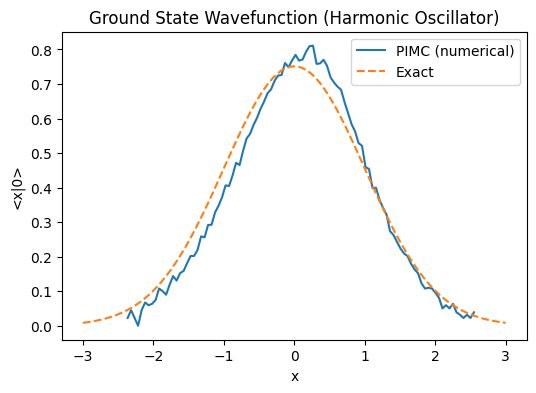

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m = 1.0
omega = 1.0
hbar = 1.0

N = 100              # number of time slices
epsilon = 0.05     # imaginary time step
beta = N * epsilon

n_steps = 50000      # total Monte Carlo steps
thermalization = 10000
delta = 1.0          # proposal step size

# Initialize path

x = np.random.normal(0, 0.5, size=N)

# Local action

def local_action(x_prev, x_curr, x_next):
    kinetic = (m / (2 * epsilon)) * ((x_curr - x_prev)**2 + (x_next - x_curr)**2)
    potential = epsilon * 0.5 * m * omega**2 * x_curr**2
    return kinetic + potential

# Metropolis update 

def metropolis_step(x):
    for j in range(N):

        x_prev = x[(j - 1) % N]
        x_curr = x[j]
        x_next = x[(j + 1) % N]

        # propose move
        x_new = x_curr + np.random.uniform(-delta, delta)

        # compute action difference
        S_old = local_action(x_prev, x_curr, x_next)
        S_new = local_action(x_prev, x_new, x_next)

        dS = S_new - S_old

        if np.random.rand() < np.exp(-dS / hbar):
            x[j] = x_new

    return x

# Sampling 

samples = []

for step in range(n_steps):

    x = metropolis_step(x)

    if step > thermalization:
        # pick a random slice (ergodicity)
        idx = np.random.randint(0, N)
        samples.append(x[idx])

# Histogram → |psi0(x)|^2
samples = np.array(samples)

hist, bins = np.histogram(samples, bins=100, density=True)
centers = 0.5 * (bins[:-1] + bins[1:])

# ground state wavefunction
psi = np.sqrt(hist)




In [ ]:
x_exact = np.linspace(-3, 3, 200)
psi_exact = (m * omega / (np.pi * hbar))**0.25 * np.exp(-m * omega * x_exact**2 / (2 * hbar))

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(centers, psi, label="PIMC (numerical)")
plt.plot(x_exact, psi_exact, '--', label="Exact")
plt.xlabel("x")
plt.ylabel("<x|0>")
plt.legend()
plt.title("Ground State Wavefunction (Harmonic Oscillator)")
plt.show()